# 02 · Exploratory Data Analysis

Understanding the business before measuring performance: how much is sold, where, through which
shipping modes, and how delivery times are distributed.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from config import CLEAN_ITEMS_PATH, CLEAN_ORDERS_PATH, IMAGES
from viz import set_style, label_bars, BLUE, ORANGE, AQUA, MUTED, TEXT_2

set_style()
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 40)

items = pd.read_csv(CLEAN_ITEMS_PATH, parse_dates=["order_date", "shipping_date"])
orders = pd.read_csv(CLEAN_ORDERS_PATH, parse_dates=["order_date", "shipping_date"])
print(f"{len(orders):,} orders | {len(items):,} order lines")

12,000 orders | 24,653 order lines

## 1. Sales trend over time

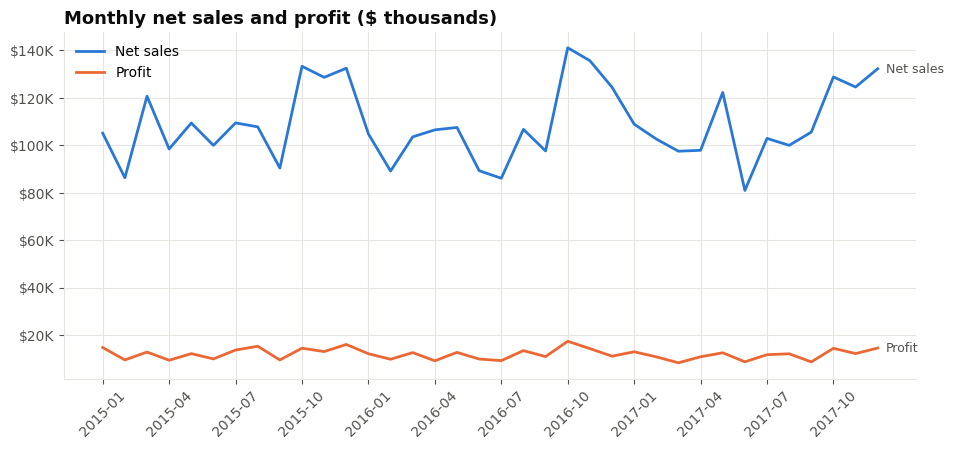

In [2]:
monthly = orders.groupby("order_month")[["net_sales", "profit"]].sum()
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly.index, monthly["net_sales"] / 1000, color=BLUE, label="Net sales")
ax.plot(monthly.index, monthly["profit"] / 1000, color=ORANGE, label="Profit")
ax.set_title("Monthly net sales and profit ($ thousands)")
ax.set_xticks(monthly.index[::3])
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}K"))
ax.legend(loc="upper left")
for name, col, c in [("Net sales", "net_sales", BLUE), ("Profit", "profit", ORANGE)]:
    ax.annotate(name, (len(monthly) - 1, monthly[col].iloc[-1] / 1000), xytext=(6, 0),
                textcoords="offset points", color=TEXT_2, va="center", fontsize=9)
plt.savefig(IMAGES / "01_monthly_sales_profit.png")

In [3]:
q = orders.groupby(orders["order_date"].dt.quarter)["net_sales"].sum()
(100 * q / q.sum()).round(1).rename("share_of_sales_%").to_frame().rename_axis("quarter").T

quarter,1,2,3,4
share_of_sales_%,23.40,23.30,23.10,30.10


Q4 carries the largest share of annual sales - the peak season that logistics capacity has to be planned for.

## 2. Where do orders come from?

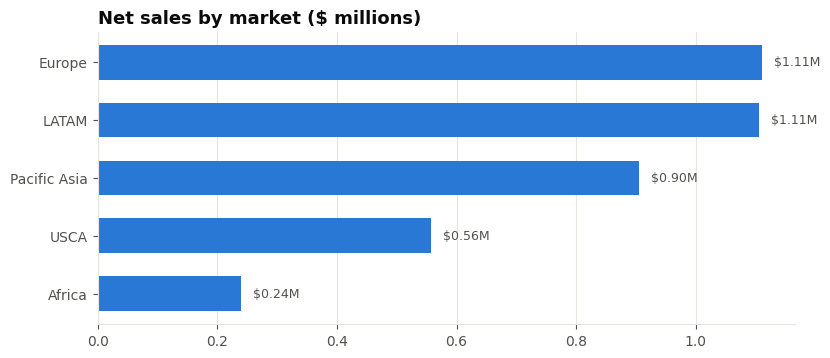

In [4]:
by_market = orders.groupby("market").agg(orders=("order_id", "count"), net_sales=("net_sales", "sum")).sort_values("net_sales")
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(by_market.index, by_market["net_sales"] / 1e6, color=BLUE, height=0.6)
ax.set_title("Net sales by market ($ millions)")
ax.grid(axis="y", visible=False)
label_bars(ax, fmt="${:.2f}M", pad=0.02)
plt.savefig(IMAGES / "02_sales_by_market.png")

## 3. Shipping mode mix

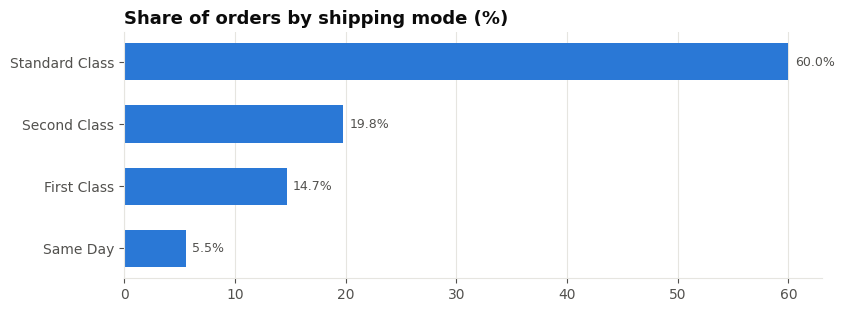

In [5]:
mode_mix = orders["shipping_mode"].value_counts(normalize=True).mul(100).sort_values()
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh(mode_mix.index, mode_mix.values, color=BLUE, height=0.6)
ax.set_title("Share of orders by shipping mode (%)")
ax.grid(axis="y", visible=False)
label_bars(ax)
plt.savefig(IMAGES / "03_shipping_mode_mix.png")

## 4. Category performance

In [6]:
cat = items.groupby("category").agg(net_sales=("net_sales", "sum"), profit=("profit", "sum"))
cat["margin_%"] = 100 * cat["profit"] / cat["net_sales"]
cat = cat.sort_values("net_sales", ascending=False)
cat.head(10)

,net_sales,profit,margin_%
category,,,
Cardio Equipment,"577,791.46","55,745.66",9.65
Fishing,"415,580.80","45,870.08",11.04
Electronics,"296,065.35","34,797.19",11.75
Camping & Hiking,"283,023.74","35,797.21",12.65
Cleats,"276,725.98","28,849.95",10.43
Computers,"270,975.00","30,046.46",11.09
Water Sports,"263,301.31","30,338.54",11.52
Accessories,"238,938.40","22,360.75",9.36
Indoor/Outdoor Games,"212,922.70","24,562.94",11.54


## 5. Delivery time distribution

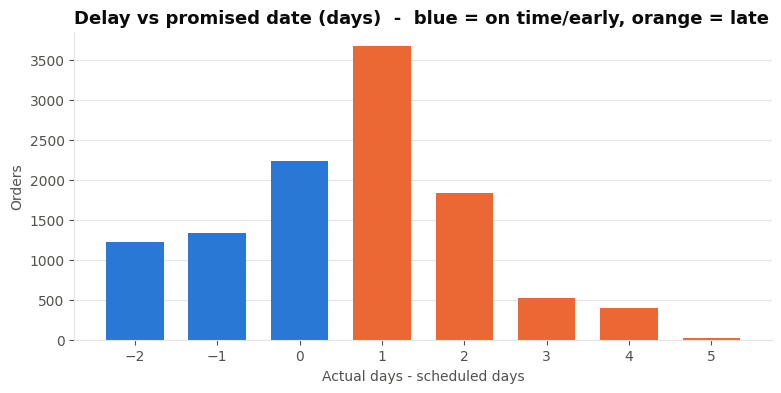

In [7]:
s = orders[orders["is_cancelled"] == 0]
dist = s["delay_days"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
colors = [ORANGE if d > 0 else BLUE for d in dist.index]
ax.bar(dist.index, dist.values, color=colors, width=0.7)
ax.set_title("Delay vs promised date (days)  -  blue = on time/early, orange = late")
ax.set_xlabel("Actual days - scheduled days")
ax.set_ylabel("Orders")
ax.grid(axis="x", visible=False)
plt.savefig(IMAGES / "04_delay_distribution.png")

## 6. Do discounts hurt profit?

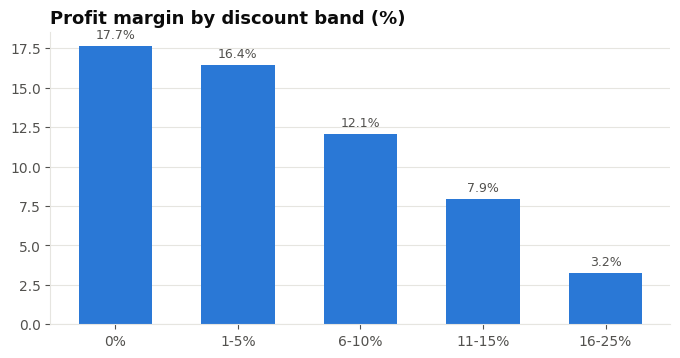

,lines,net_sales,profit,loss_lines_pct,margin_%
discount_band,,,,,
0%,1717,"306,628.94","54,174.71",22.13,17.67
1-5%,7058,"1,223,197.32","201,167.25",23.65,16.45
6-10%,5300,"846,845.13","102,159.83",30.87,12.06
11-15%,3538,"546,057.87","43,217.86",35.78,7.91
16-25%,7040,"994,820.46","32,290.77",44.09,3.25


In [8]:
disc = items.assign(discount_band=pd.cut(items["discount_rate"], [-0.01, 0.0, 0.05, 0.10, 0.15, 0.25],
                                         labels=["0%", "1-5%", "6-10%", "11-15%", "16-25%"]))
disc_tbl = disc.groupby("discount_band", observed=True).agg(lines=("order_item_id", "count"),
                                            net_sales=("net_sales", "sum"), profit=("profit", "sum"),
                                            loss_lines_pct=("is_loss", "mean"))
disc_tbl["margin_%"] = 100 * disc_tbl["profit"] / disc_tbl["net_sales"]
disc_tbl["loss_lines_pct"] *= 100

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(disc_tbl.index.astype(str), disc_tbl["margin_%"], color=BLUE, width=0.6)
ax.set_title("Profit margin by discount band (%)")
ax.grid(axis="x", visible=False)
label_bars(ax, horizontal=False, pad=0.3)
plt.savefig(IMAGES / "05_margin_by_discount.png")
disc_tbl

### EDA summary
- Sales are seasonal, with a Q4 peak.
- LATAM and Europe are the two biggest markets.
- **Standard Class carries the majority of orders**, so its performance drives the overall numbers.
- A large share of orders arrive after the promised date - explored in detail in notebook 03.
- Profit margin falls steadily as discounts rise - deep discounts create loss-making lines.